# **Internship Project -  HeartDieseasePred**

# Bussiness case:-

* Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

* People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

# Problem Statement and Goals:

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:- Create a model predicting potential Heart Diseases in people using Machine Learning algorithms.

Task3:-Suggestions to the Hospital  to awake the predictions of heart diseases  prevent life threats.


#  DataSet Source and Description.


- **Source** : Institute
- **Rows** : 180
- **Columns** : 15
- **Traget Variable** :heart_disease_present
- **Features** : Mixture of numerical and Categorical Variable

# Import and Configuration:-

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("Heart disease.csv")


In [3]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


# Domain Analysis:-

1. **patient_id** – Unique identifier for each patient, used only for record tracking (no predictive value).

2. **slope_of_peak_exercise_st_segment** – Describes the slope of the ST segment during peak exercise, reflecting heart stress response.

3. **thal** – Thalassemia test result indicating normal, fixed defect, or reversible defect in blood flow.

4. **resting_blood_pressure** – Patient’s blood pressure measured at rest, an important cardiovascular risk indicator.

5. **chest_pain_type** – Categorizes the type of chest pain experienced, strongly associated with heart disease.

6. **num_major_vessels** – Number of major blood vessels colored by fluoroscopy, indicating vessel blockage severity.

7. **fasting_blood_sugar_gt_120_mg_per_dl** – Binary indicator of whether fasting blood sugar exceeds 120 mg/dL (diabetes risk).

8. **resting_ekg_results** – Electrocardiographic results at rest, showing heart rhythm and electrical abnormalities.

9. **serum_cholesterol_mg_per_dl** – Cholesterol level in blood, a key factor in plaque buildup and heart disease.

10. **oldpeak_eq_st_depression** – ST depression induced by exercise compared to rest, indicating myocardial ischemia.

11. **sex** – Biological sex of the patient, as heart disease risk differs between males and females.

12. **age** – Age of the patient, a major non-modifiable risk factor for heart disease.

13. **max_heart_rate_achieved** – Maximum heart rate reached during exercise, reflecting cardiovascular fitness.

14. **exercise_induced_angina** – Indicates whether chest pain occurs during exercise, signaling reduced blood flow to the heart

15. **heart_disease_present** – Target variable indicating whether the patient has heart disease (1 = Yes, 0 = No).


# Basic Check:

In [4]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [6]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [7]:
df.describe(include='O')

,patient_id,thal
count,180,180
unique,180,3
top,0z64un,normal
freq,1,98


In [8]:
df.shape

(180, 15)

# __EDA__

In [9]:
num_colms=df.select_dtypes(include=['int64','float']).columns 

In [10]:
cat_colms=df.select_dtypes(include=['object']).columns

In [11]:
num_colms

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [12]:
cat_colms

Index(['patient_id', 'thal'], dtype='object')

# __Univariant Analysis__

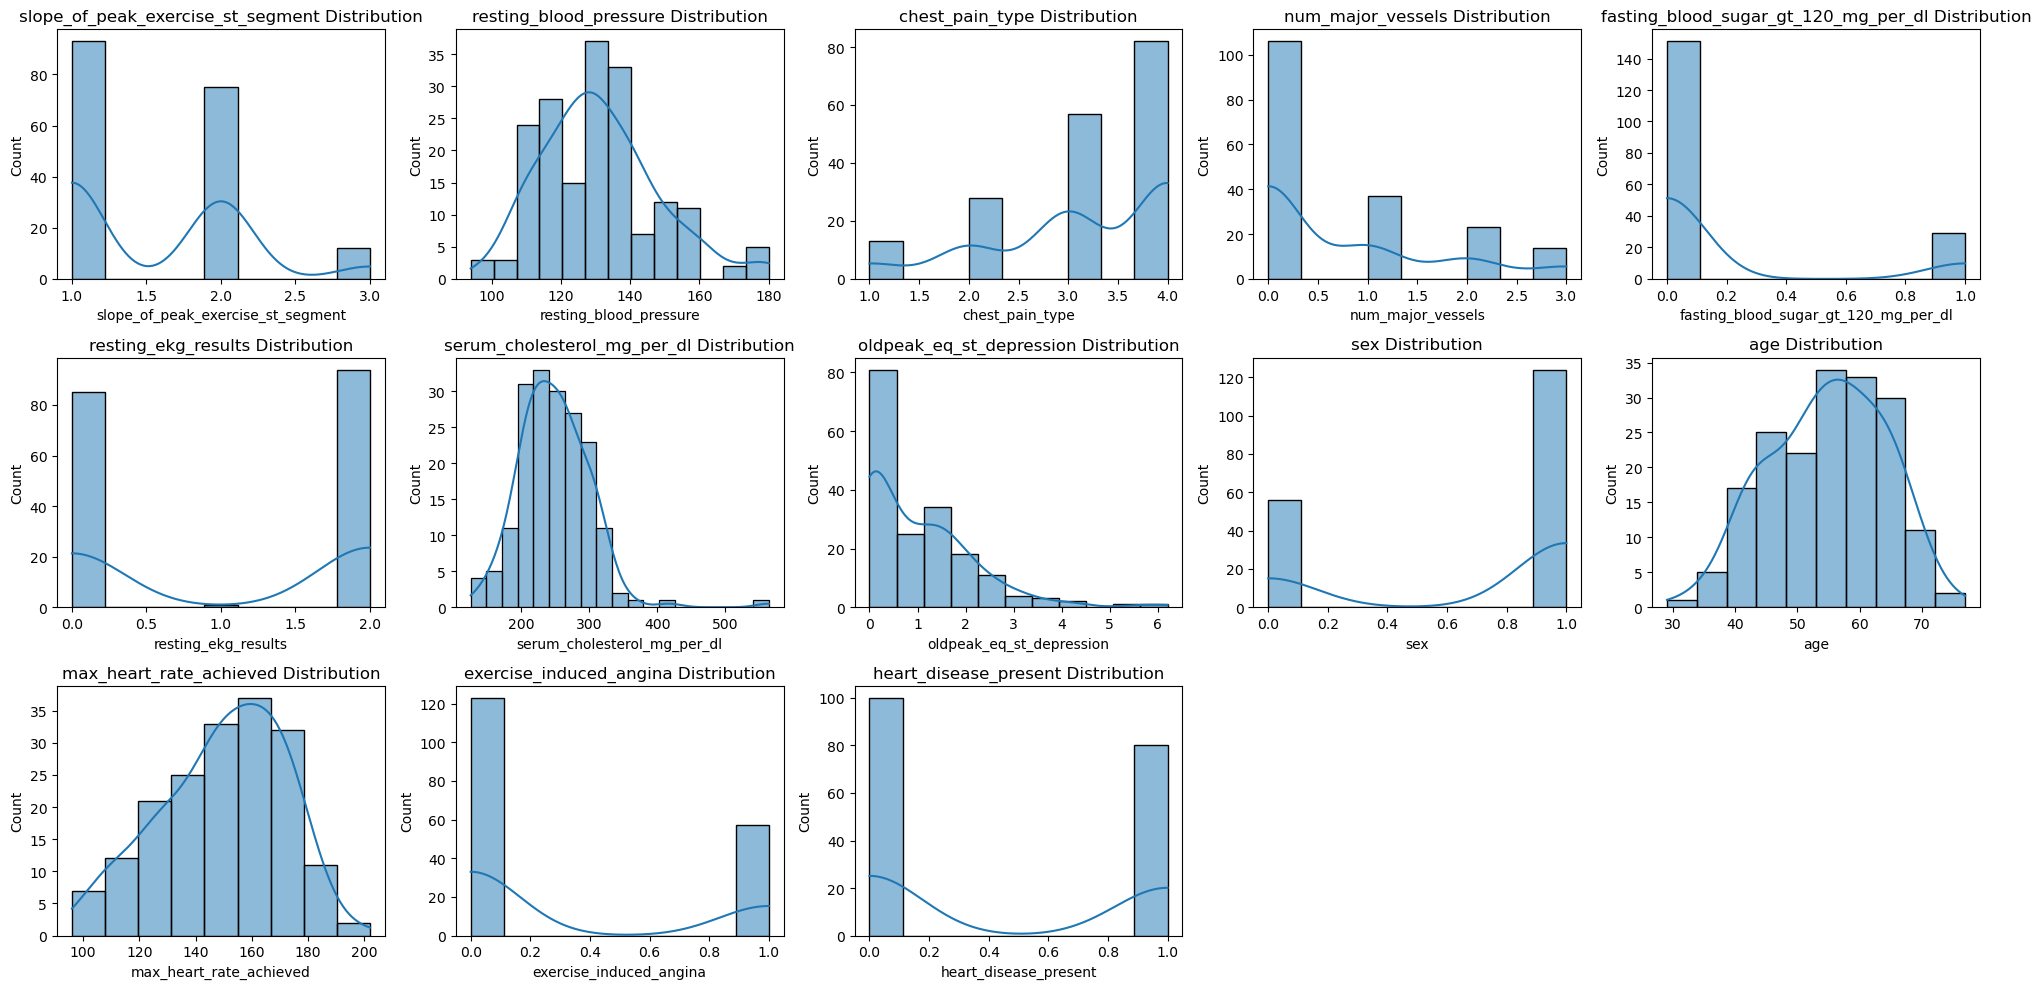

In [13]:
pltn = 1
plt.figure(figsize=(20,10))

for col in num_colms:
    plt.subplot(3,5,pltn)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    pltn += 1

plt.tight_layout()
plt.show()

insights:

- Most patients are middle-aged males, and the dataset contains more male records than female.
- Health measurements like resting blood pressure, cholesterol, and maximum heart rate are mostly in normal to moderate range, but a few extreme values (outliers) are present.
- Medical condition features such as chest pain type, ECG results, slope, number of major vessels, and exercise-induced angina show uneven distribution, meaning some categories are much more common than others.
- Risk indicators like high fasting blood sugar and high ST depression (oldpeak) are less frequent, as most patients have normal values.
- The target variable heart_disease_present contains both classes, but there is slight imbalance, indicating one group has more patients than the other.
- If you want more short (one-line each column) or ML feature importance insights, I can give that too.

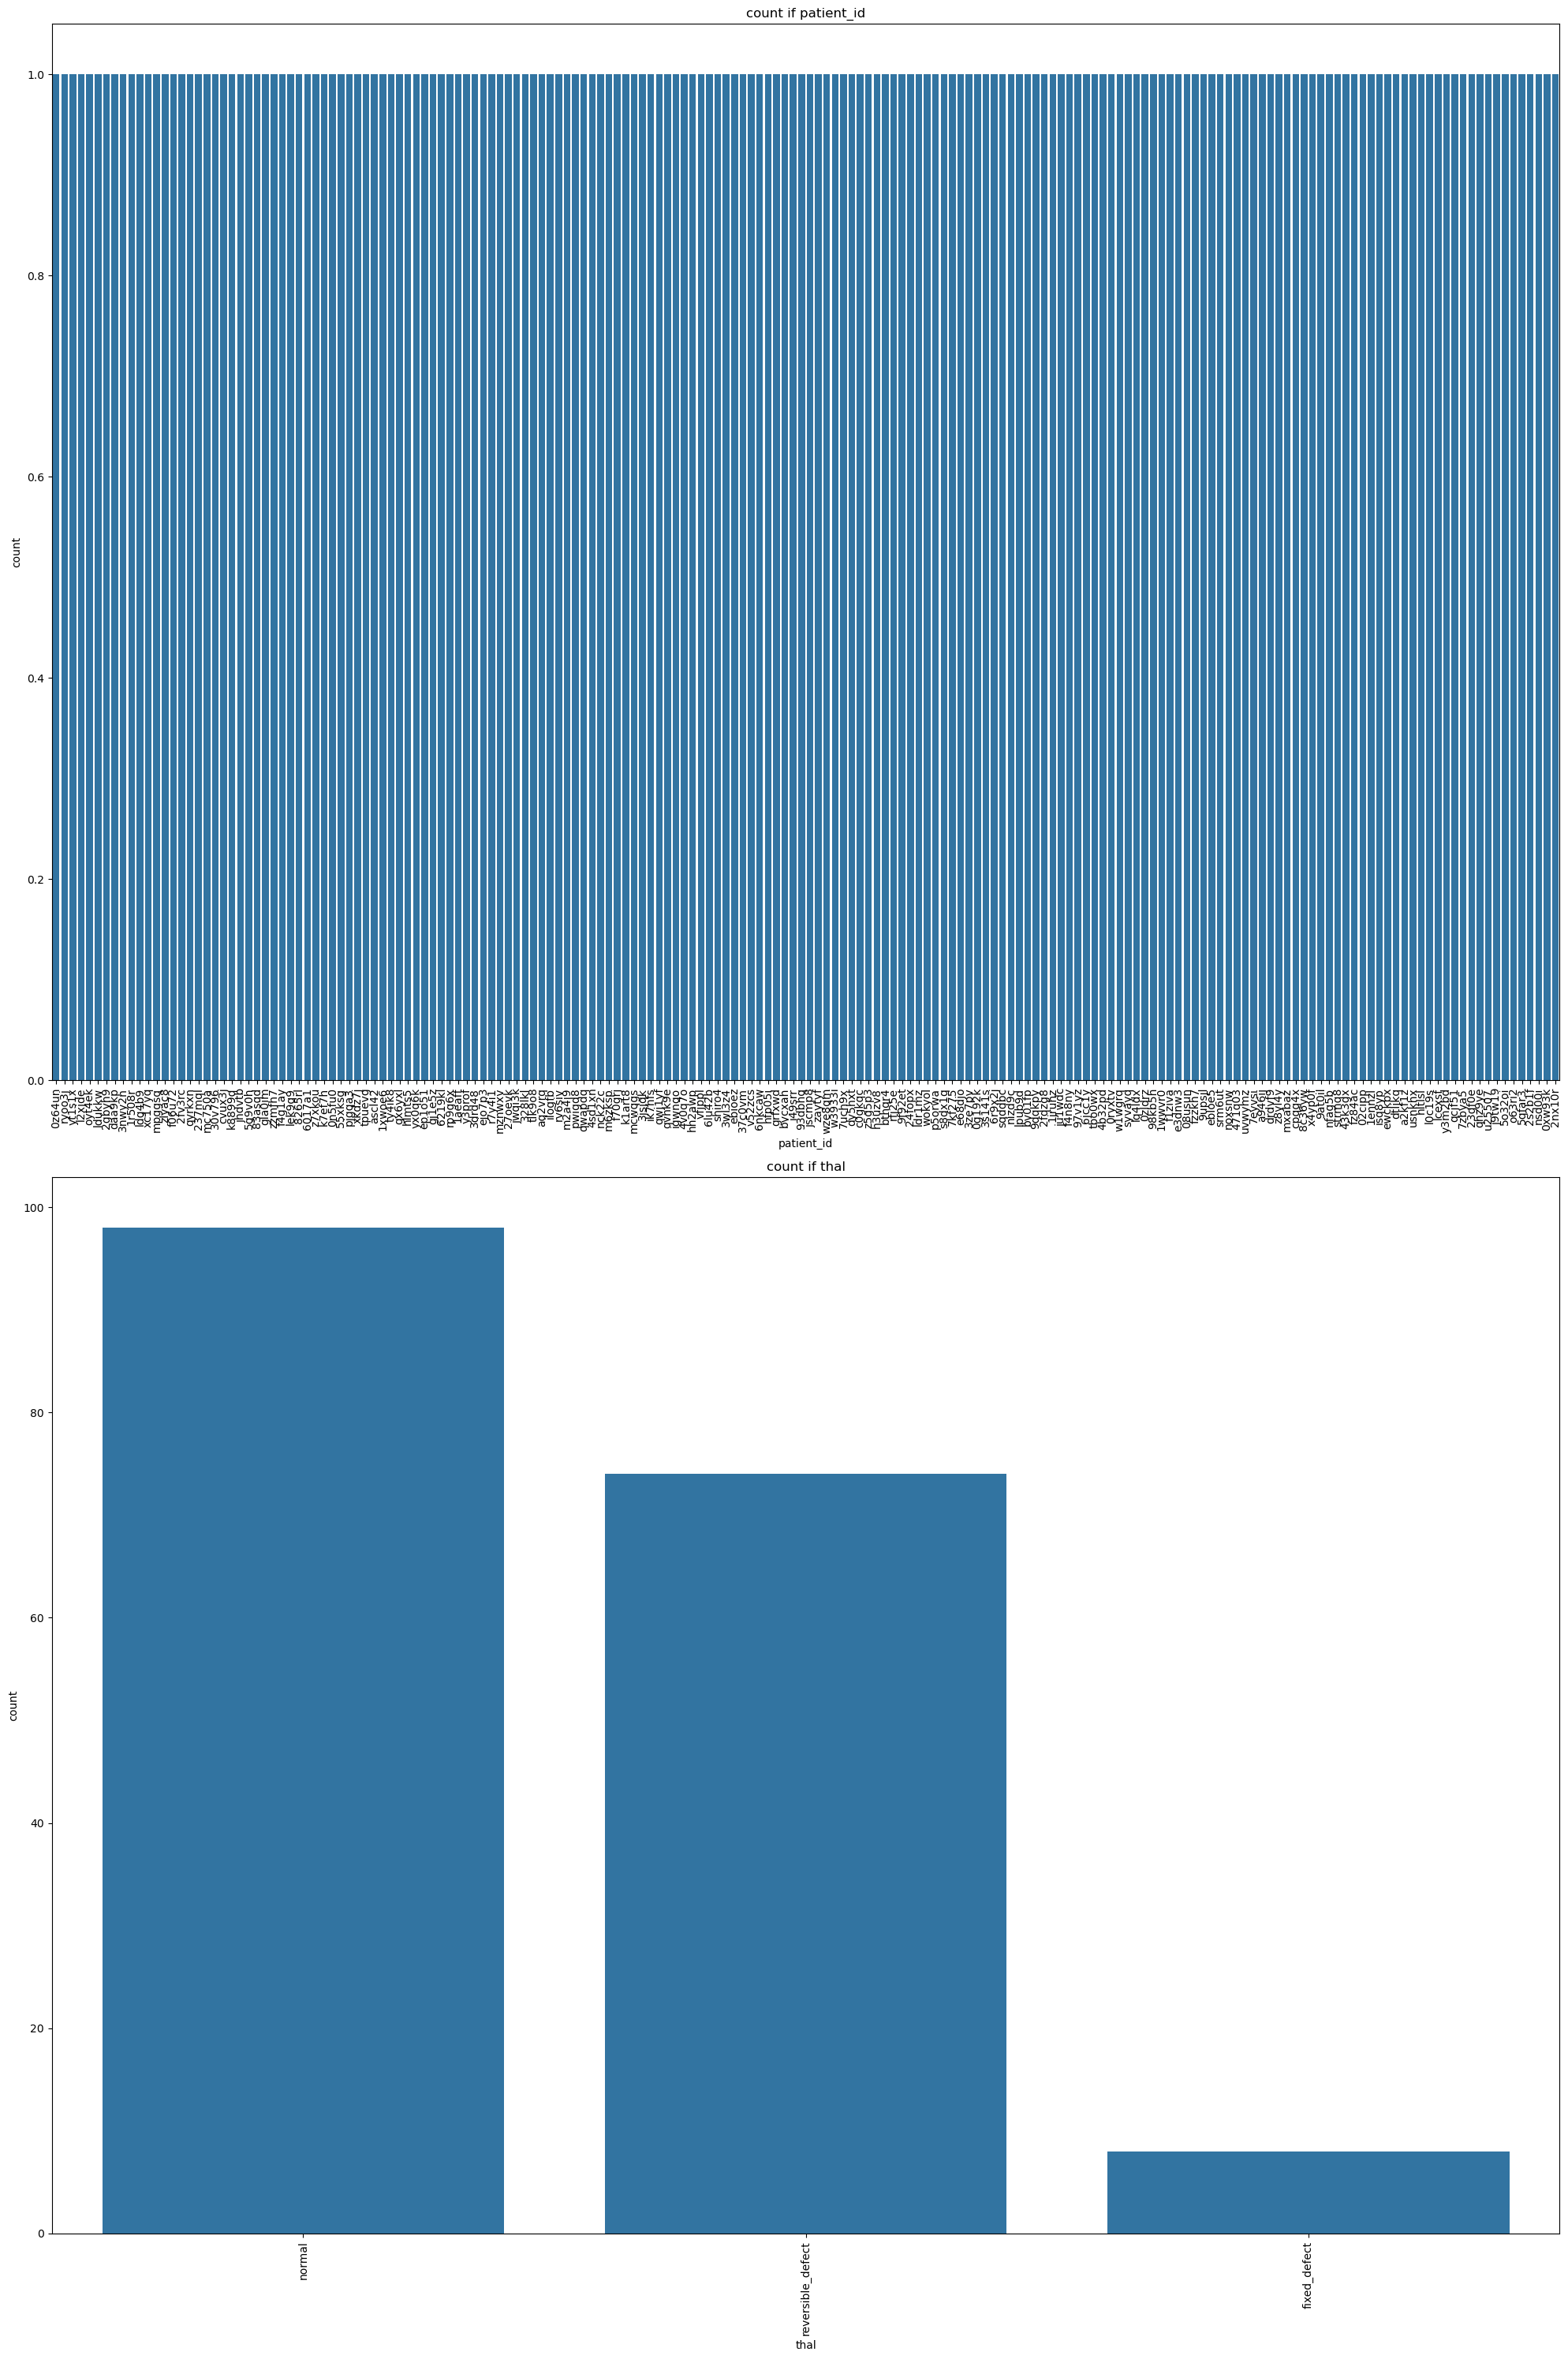

In [14]:
plot = 1
plt.figure (figsize=(20,30))


for i in cat_colms:
    if plot<=43:
        plt.subplot(2,1,plot)
        sns.countplot(x=i,data=df)
        plt.title(f'count if {i}')
        plt.xticks(rotation=90)
        plot += 1 

plt.tight_layout()
plt.show()

insights:

- Most patients are middle-aged males, and the dataset contains more male records than female.
- Health measurements like resting blood pressure, cholesterol, and maximum heart rate are mostly in normal to moderate range, but a few extreme values (outliers) are present.
- Medical condition features such as chest pain type, ECG results, slope, number of major vessels, and exercise-induced angina show uneven distribution, meaning some categories are much more common than others.
- Risk indicators like high fasting blood sugar and high ST depression (oldpeak) are less frequent, as most patients have normal values.
- The target variable heart_disease_present contains both classes, but there is slight imbalance, indicating one group has more patients than the other.
- If you want more short (one-line each column) or ML feature importance insights, I can give that too.

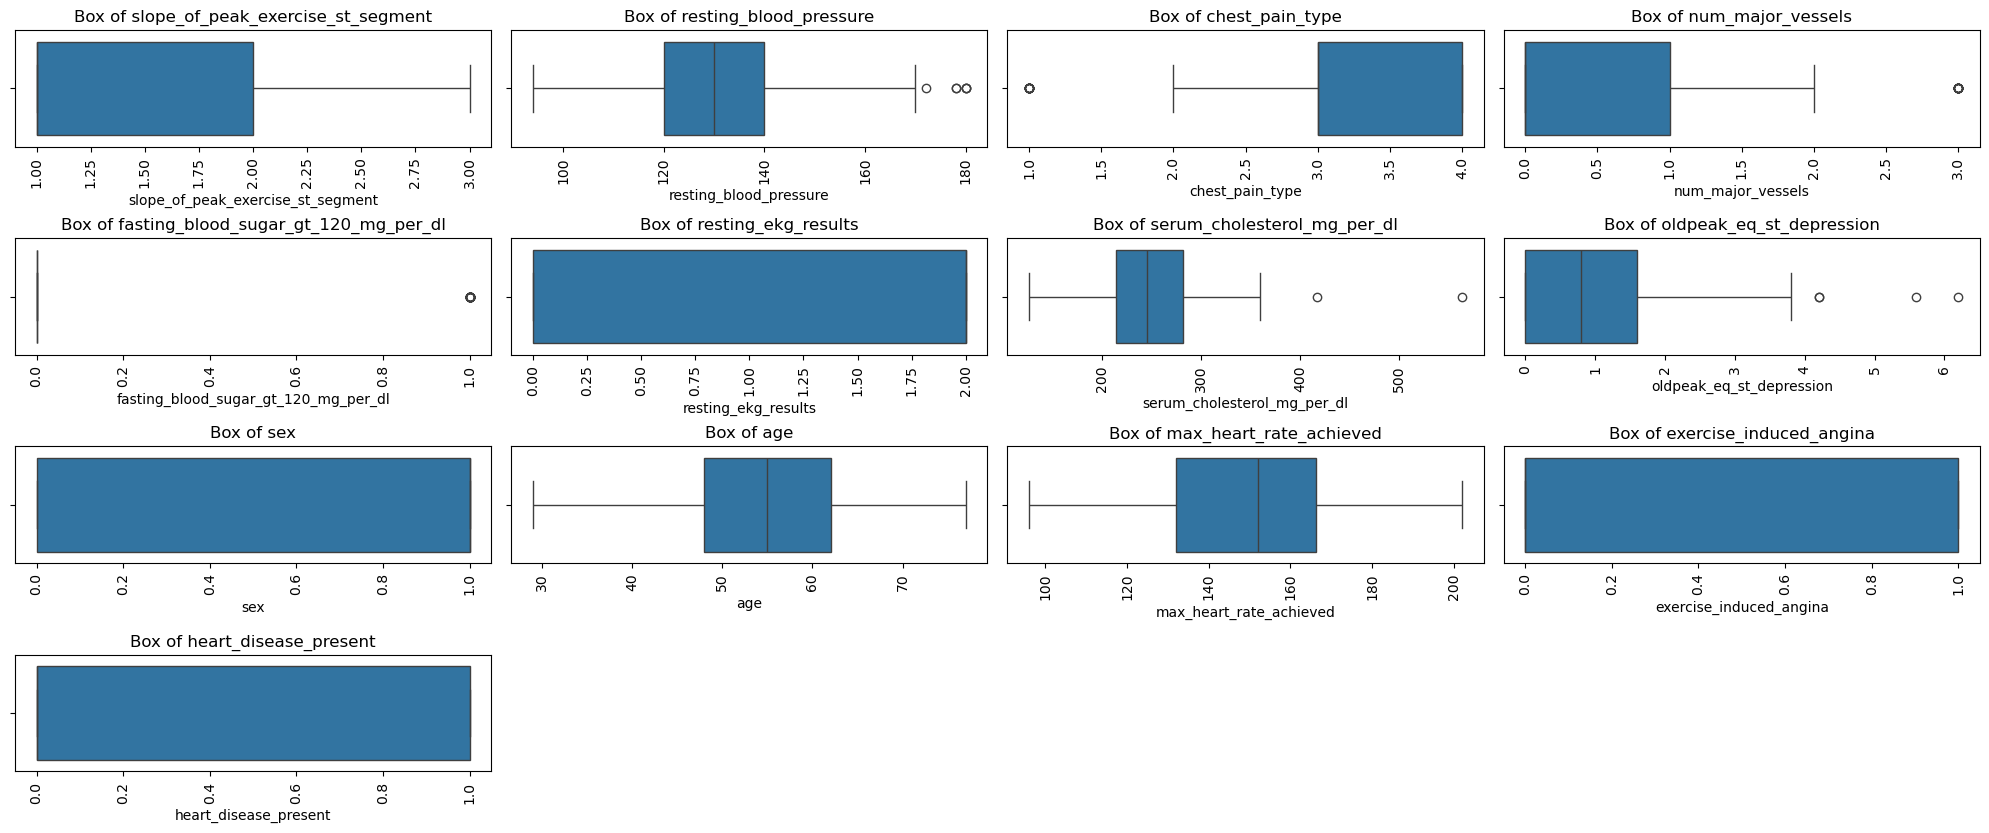

In [15]:
plt.figure(figsize=(20,10))
plot=1

for i in num_colms:
    if plot<=20:
        plt.subplot(5,4,plot)
        sns.boxplot(x=i,data=df)
        plt.title(f'Box of {i}')
        plt.xticks(rotation=90)
        plot += 1

plt.tight_layout()
plt.show()
        

#### insights

- Features like resting
- blood_pressure, serum_cholesterol_mg_per_dl, oldpeak_eq_st_depression, and max_heart_rate_achieved show some outliers, which means a few patients have very high or very low values.
- The age column has a moderate spread, and most patients fall in the middle age range with very few extreme values.
- Medical measurement features such as blood pressure and cholesterol have wider variation, indicating differences in patient health conditions.
- Columns like sex, chest_pain_type, fasting_blood_sugar_gt_120_mg_per_dl, exercise_induced_angina, and heart_disease_present show limited spread because they contain categorical or binary values.
- Overall, only a few continuous features contain significant outliers, so outlier treatment may be needed for better Machine Learning model performance.

# Bivariant Anaylsis.

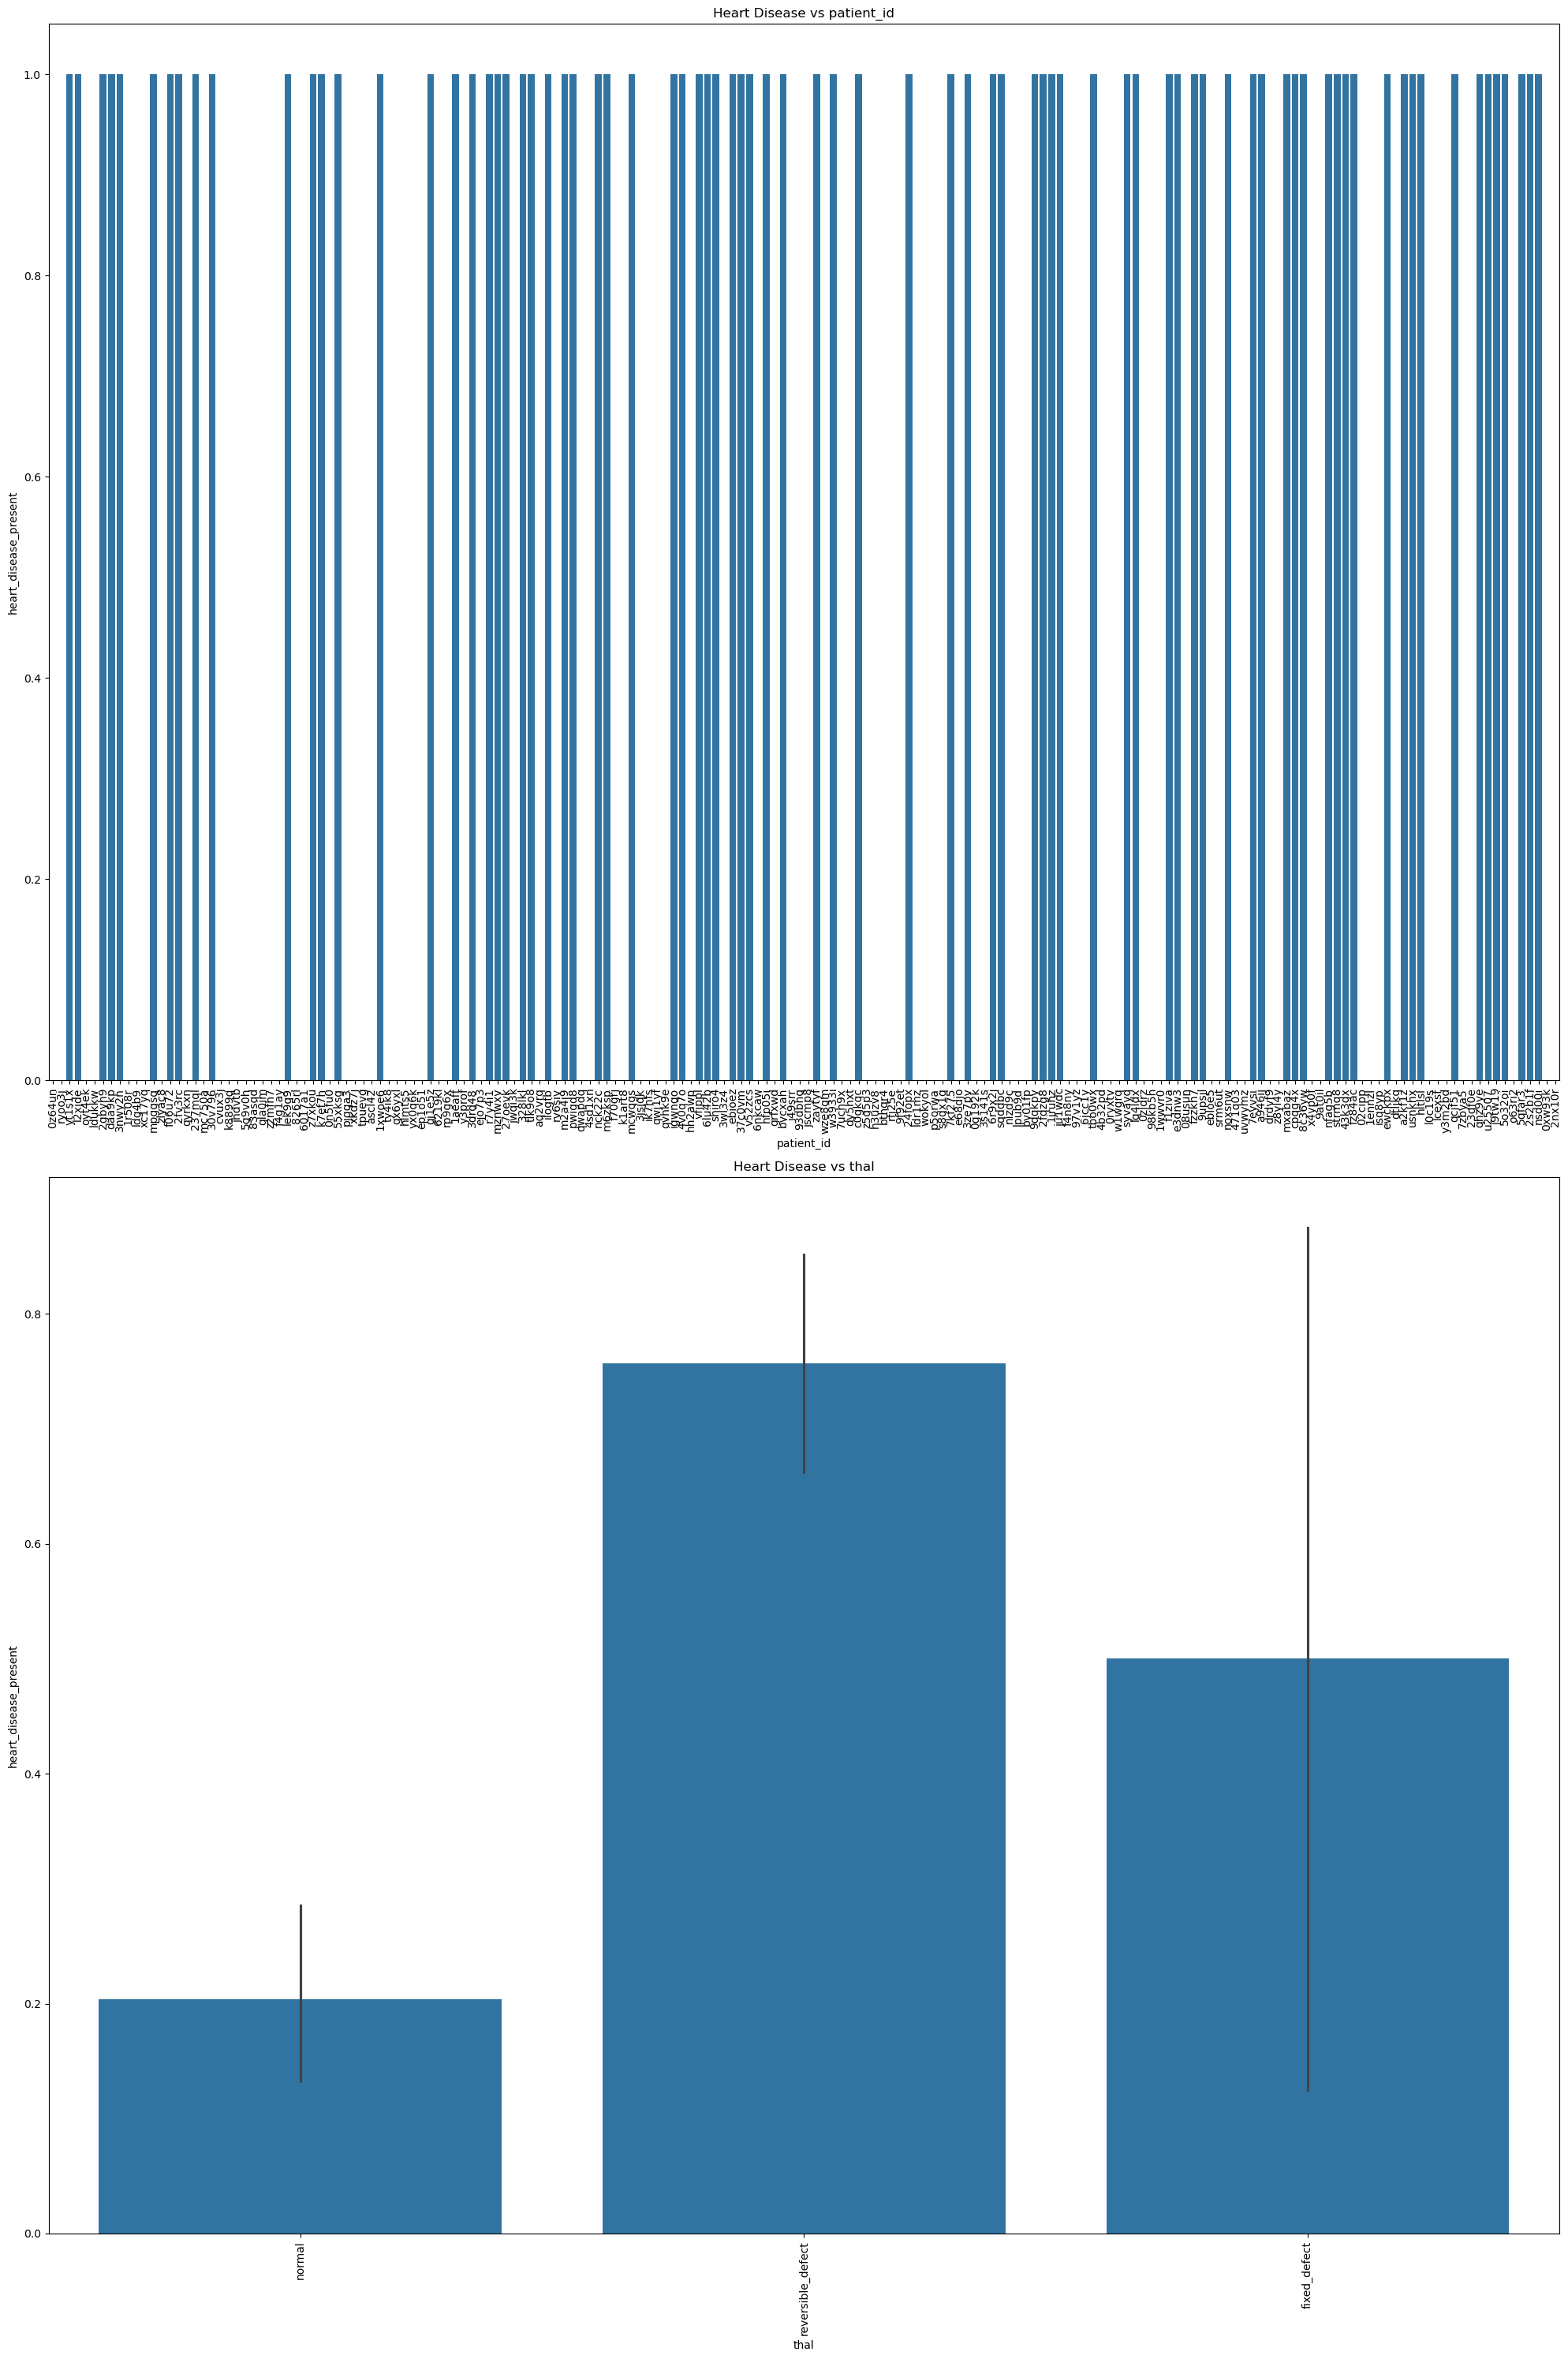

In [16]:

plt.figure(figsize=(20, 30))
plot = 1

for i in cat_colms:   
    plt.subplot(2, 1, plot)
    sns.barplot(x=i, y='heart_disease_present', data=df)   
    plt.title(f"Heart Disease vs {i}")
    plt.xticks(rotation=90)       
    plot += 1

plt.tight_layout()
plt.show()

Insight:

- Patients with reversible_defect have the highest average heart disease presence compared to other groups.
- Patients with fixed_defect also show a higher risk of heart disease than normal patients.
- Patients with normal thal have the lowest heart disease presence, indicating lower risk.
- The difference between normal and defect groups shows that the thal feature is important for predicting heart disease.
- The wide error bar in fixed_defect indicates higher variation, meaning the risk level is not consistent for all patients.

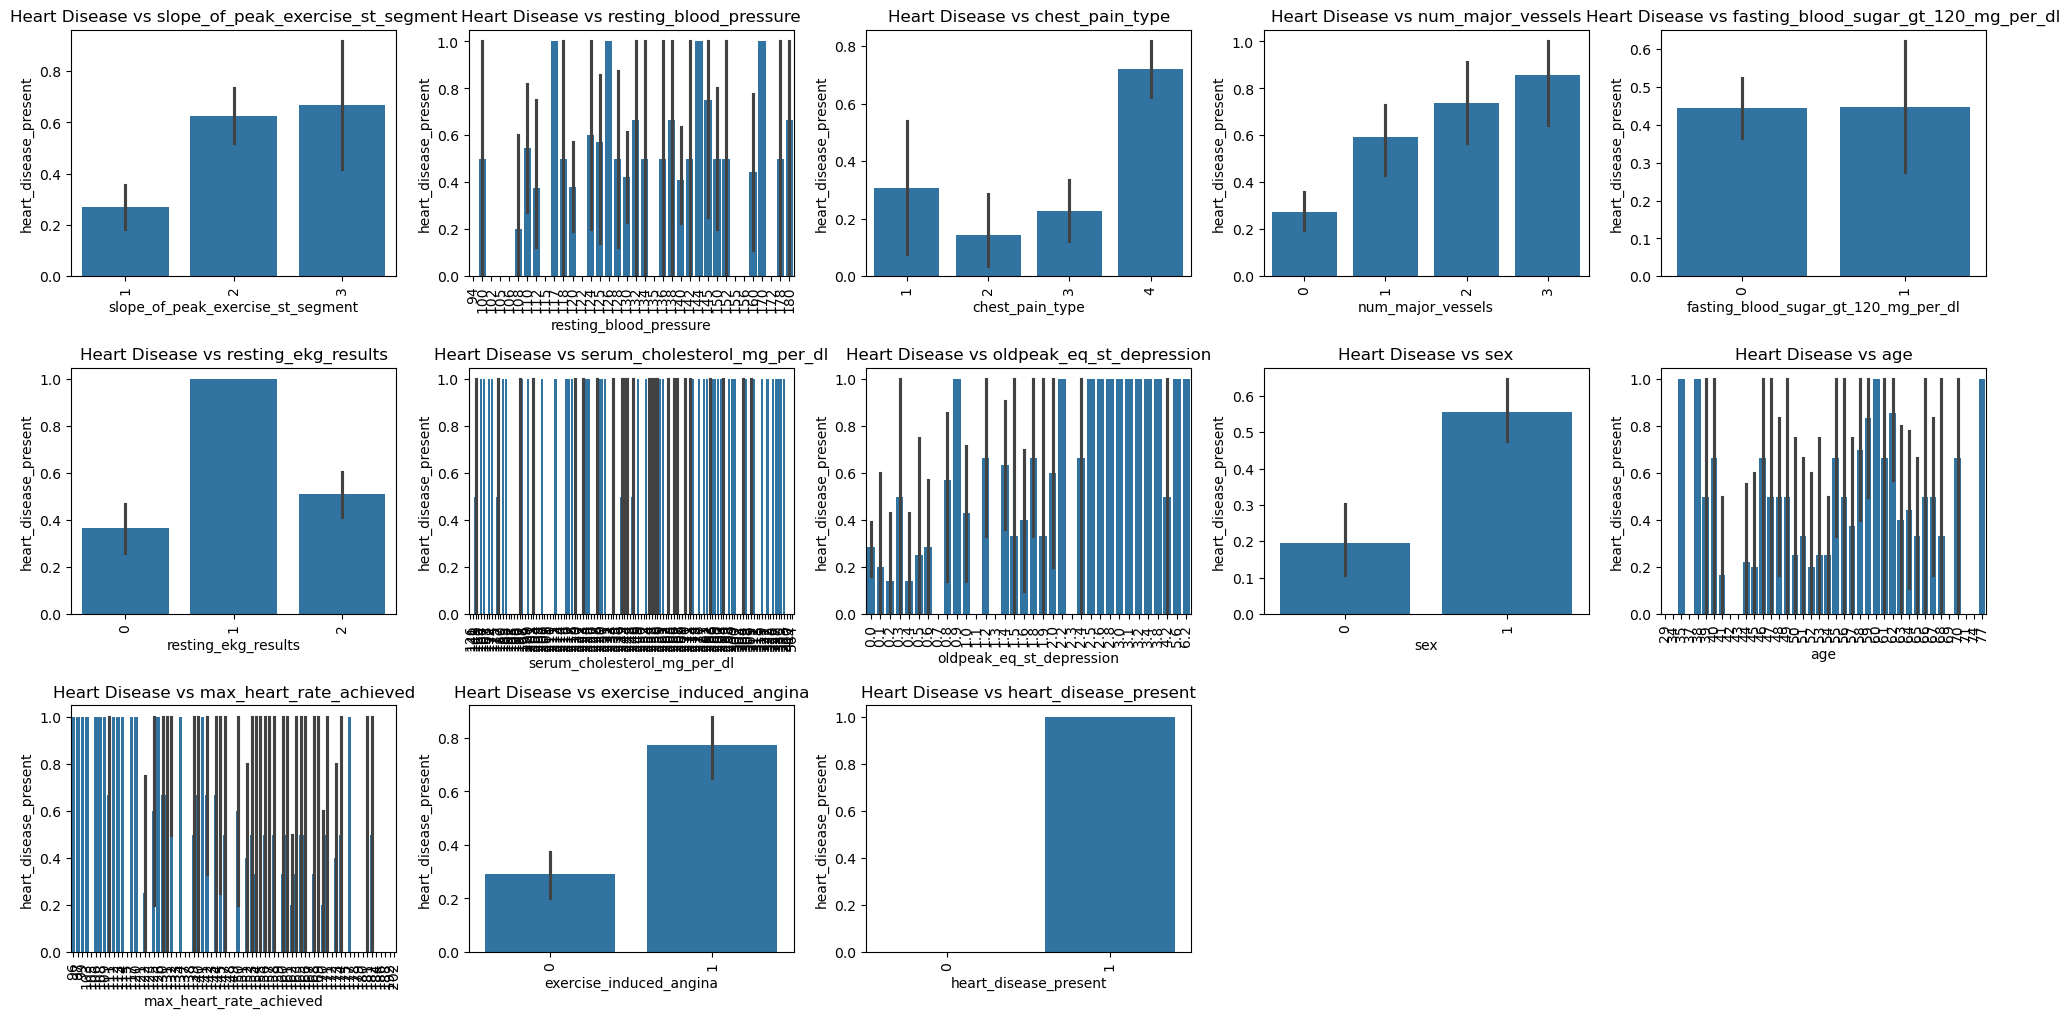

In [17]:

plt.figure(figsize=(20, 30))
plot = 1

for i in num_colms:   
    plt.subplot(9, 5, plot)
    sns.barplot(x=i, y='heart_disease_present', data=df)   
    plt.title(f"Heart Disease vs {i}")
    plt.xticks(rotation=90)       
    plot += 1

plt.tight_layout()
plt.show()

Insight:

- As age increases, the chance of heart disease also increases, showing older patients have higher risk.
- Patients with higher oldpeak (ST depression) show more heart disease presence, so this feature is strongly related to the target.
- Lower max heart rate achieved is associated with higher heart disease risk.
- Higher resting blood pressure and serum cholesterol slightly increase the chance of heart disease, but the effect is moderate.
- Patients with higher number of major vessels show a much higher heart disease presence, making it an important feature for prediction.

# Multivariant Analysis:

<Axes: >

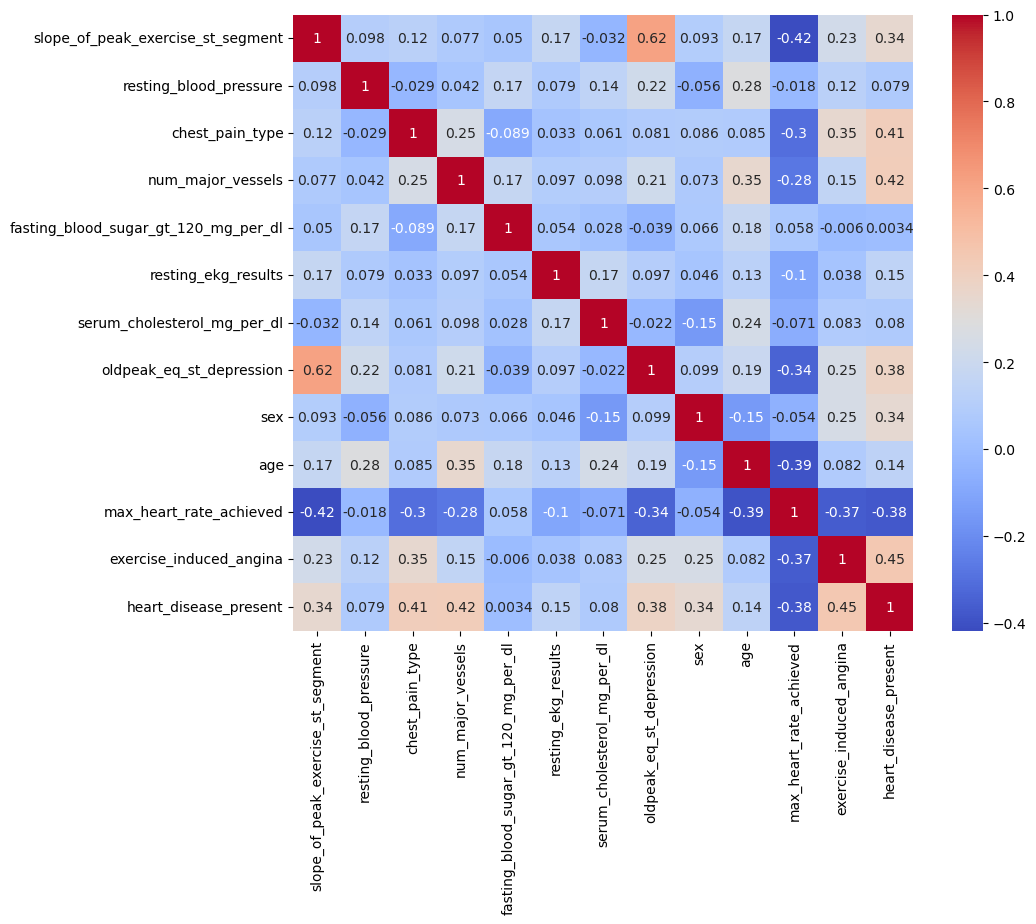

In [18]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")

#### insights

- heart_disease_present has a strong positive relationship with exercise_induced_angina (0.45), num_major_vessels (0.42), and chest_pain_type (0.41), which means these features increase the risk of heart disease.
- heart_disease_present has a negative relationship with max_heart_rate_achieved (-0.38) and age (-0.14), showing that lower heart rate during exercise is linked with higher disease risk.
- oldpeak_eq_st_depression is strongly related to slope_of_peak_exercise_st_segment (0.62), indicating these two exercise ECG features are highly connected.
- age has a negative correlation with max_heart_rate_achieved (-0.39), which means older patients tend to achieve lower maximum heart rate.
- Most other features show low correlation with each other, so there is low multicollinearity, and most variables can be safely used in the Machine Learning model.

# Feature Engineering:

## Null Value Handling:

In [19]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [20]:
df.drop(['patient_id'], axis=1, inplace=True)

# Outlier Handaling:

In [21]:
num_colms=[ 'slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present']

for i in num_colms:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
        
    # Define Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
        
    # Find outliers
    outliers_upper = df[df[i] > upper_bound]
    outliers_lower = df[df[i] < lower_bound]
    print(f"{i} -Upper outliers: {outliers_upper.shape}, Lower outliers: {outliers_lower.shape}")
        
    # Cap outliers using .loc
    df.loc[df[i] > upper_bound, i] = upper_bound
    df.loc[df[i] < lower_bound, i] = lower_bound

slope_of_peak_exercise_st_segment -Upper outliers: (0, 14), Lower outliers: (0, 14)
resting_blood_pressure -Upper outliers: (6, 14), Lower outliers: (0, 14)
chest_pain_type -Upper outliers: (0, 14), Lower outliers: (13, 14)
num_major_vessels -Upper outliers: (14, 14), Lower outliers: (0, 14)
fasting_blood_sugar_gt_120_mg_per_dl -Upper outliers: (29, 14), Lower outliers: (0, 14)
resting_ekg_results -Upper outliers: (0, 14), Lower outliers: (0, 14)
serum_cholesterol_mg_per_dl -Upper outliers: (2, 14), Lower outliers: (0, 14)
oldpeak_eq_st_depression -Upper outliers: (4, 14), Lower outliers: (0, 14)
sex -Upper outliers: (0, 14), Lower outliers: (0, 14)
age -Upper outliers: (0, 14), Lower outliers: (0, 14)
max_heart_rate_achieved -Upper outliers: (0, 14), Lower outliers: (0, 14)
exercise_induced_angina -Upper outliers: (0, 14), Lower outliers: (0, 14)
heart_disease_present -Upper outliers: (0, 14), Lower outliers: (0, 14)


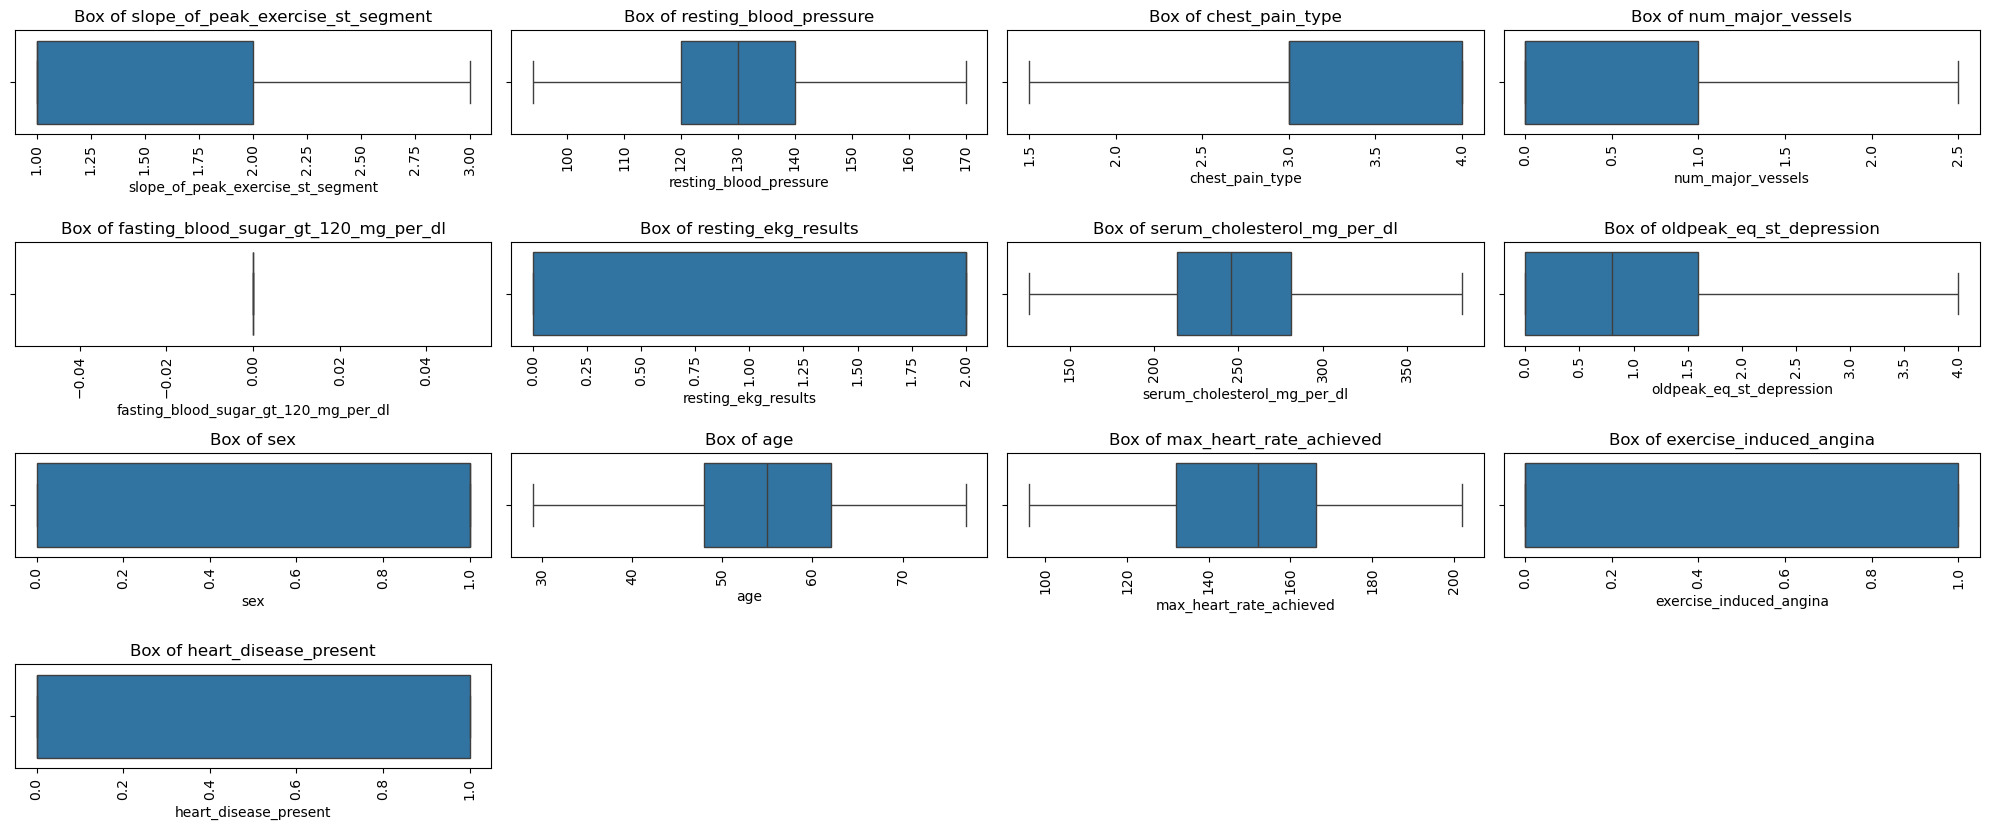

In [22]:
plt.figure(figsize=(20, 10))
plot = 1

for i in num_colms:   
    if plot <= 20:
        plt.subplot(5, 4, plot)
        sns.boxplot(x=i, data=df)   
        plt.title(f"Box of {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

## Encoding

In [23]:
label_features = ['thal']

In [24]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

for i in label_features:
    df[i] = LE.fit_transform(df[i])
    print(df[i])

0      1
1      1
2      1
3      2
4      2
      ..
175    2
176    1
177    2
178    1
179    1
Name: thal, Length: 180, dtype: int64


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    float64
 1   thal                                  180 non-null    int64  
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    float64
 4   num_major_vessels                     180 non-null    float64
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    float64
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    float64
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

## Feature Selection

In [26]:
corr_matrix=df.corr()

In [27]:
corr_matrix

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
slope_of_peak_exercise_st_segment,1.000000,0.154101,0.092748,0.147084,0.072698,NaN,0.172191,-0.047721,0.614943,0.093340,0.169918,-0.418102,0.225459,0.344224
thal,0.154101,1.000000,-0.012616,0.283811,0.175438,NaN,-0.052171,0.030316,0.247317,0.265420,-0.007934,-0.142098,0.360395,0.447214
resting_blood_pressure,0.092748,-0.012616,1.000000,-0.013540,0.046710,NaN,0.083871,0.173974,0.203517,-0.048326,0.283972,-0.015768,0.111932,0.077279
chest_pain_type,0.147084,0.283811,-0.013540,1.000000,0.260455,NaN,0.050523,0.069693,0.110239,0.108110,0.106384,-0.324497,0.376688,0.438489
num_major_vessels,0.072698,0.175438,0.046710,0.260455,1.000000,NaN,0.089455,0.129027,0.204281,0.071126,0.363012,-0.269822,0.158022,0.426700
fasting_blood_sugar_gt_120_mg_per_dl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_ekg_results,0.172191,-0.052171,0.083871,0.050523,0.089455,NaN,1.000000,0.165108,0.103162,0.045786,0.126856,-0.102766,0.037773,0.145933
serum_cholesterol_mg_per_dl,-0.047721,0.030316,0.173974,0.069693,0.129027,NaN,0.165108,1.000000,-0.012666,-0.131063,0.229393,-0.090217,0.109297,0.110973
oldpeak_eq_st_depression,0.614943,0.247317,0.203517,0.110239,0.204281,NaN,0.103162,-0.012666,1.000000,0.117856,0.195838,-0.349878,0.264079,0.391121
sex,0.093340,0.265420,-0.048326,0.108110,0.071126,NaN,0.045786,-0.131063,0.117856,1.000000,-0.148997,-0.053960,0.251096,0.335421


## Correlation with target

In [28]:
heart_disease_present_corr = corr_matrix['heart_disease_present'].sort_values(ascending=False)
heart_disease_present_corr

heart_disease_present                   1.000000
exercise_induced_angina                 0.448647
thal                                    0.447214
chest_pain_type                         0.438489
num_major_vessels                       0.426700
oldpeak_eq_st_depression                0.391121
slope_of_peak_exercise_st_segment       0.344224
sex                                     0.335421
resting_ekg_results                     0.145933
age                                     0.138255
serum_cholesterol_mg_per_dl             0.110973
resting_blood_pressure                  0.077279
max_heart_rate_achieved                -0.375352
fasting_blood_sugar_gt_120_mg_per_dl         NaN
Name: heart_disease_present, dtype: float64

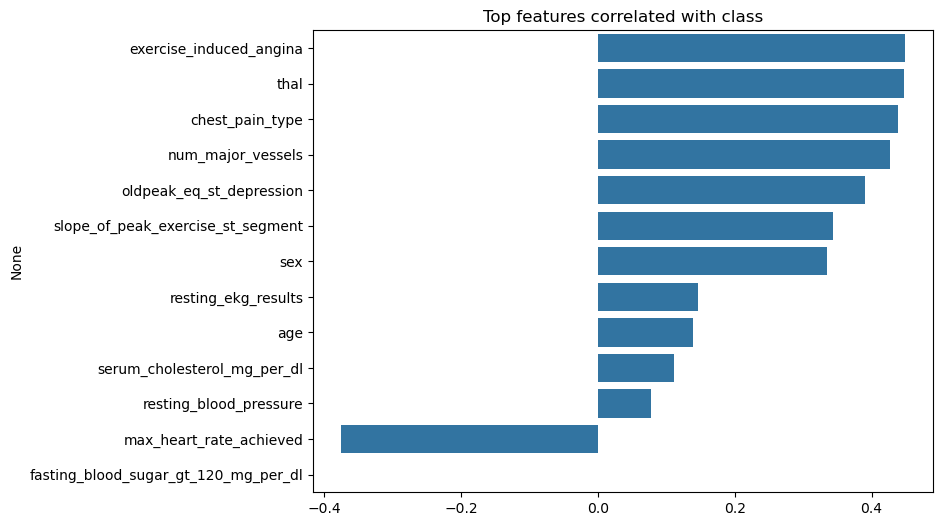

In [29]:
top_corr = heart_disease_present_corr[1:15]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top features correlated with class")
plt.show()

Insight

- Exercise_induced_angina shows the highest positive correlation with heart disease, which means patients who experience angina during exercise have a higher risk.
- Thal and chest_pain_type also have strong positive relationships, indicating that abnormal thal results and certain chest pain types are important risk indicators.
- Num_major_vessels and oldpeak_eq_st_depression are strongly positively correlated, showing that blocked vessels and higher ST depression increase the chance of heart disease.
- Slope_of_peak_exercise_st_segment and sex have moderate positive correlation, suggesting that exercise ECG slope patterns and male gender are linked to higher risk.
- Max_heart_rate_achieved shows a negative correlation, meaning patients who achieve lower maximum heart rate during exercise are more likely to have heart disease, while features like fasting blood sugar, cholesterol, and resting blood pressure have very low impact.

In [30]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

high_corr

[]

### Dropping Columns

In [31]:
drop_cols = [ 'fasting_blood_sugar_gt_120_mg_per_dl',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'age',
    'resting_ekg_results'
]

df_clean = df.drop(columns=drop_cols)
df_clean.head()

,slope_of_peak_exercise_st_segment,thal,chest_pain_type,num_major_vessels,oldpeak_eq_st_depression,sex,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1.0,1,2.0,0.0,0.0,1.0,170.0,0.0,0.0
1,2.0,1,3.0,0.0,1.6,0.0,158.0,0.0,0.0
2,1.0,1,4.0,2.5,0.0,1.0,162.0,1.0,1.0
3,1.0,2,4.0,0.0,0.0,1.0,181.0,0.0,1.0
4,3.0,2,1.5,0.0,4.0,1.0,145.0,0.0,0.0


## Model

In [32]:
X = df.drop("heart_disease_present",axis=1)
y = df.heart_disease_present

In [33]:
X

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,1.0,1,128,2.0,0.0,0,2,308.0,0.0,1.0,45,170.0,0.0
1,2.0,1,110,3.0,0.0,0,0,214.0,1.6,0.0,54,158.0,0.0
2,1.0,1,125,4.0,2.5,0,2,304.0,0.0,1.0,77,162.0,1.0
3,1.0,2,152,4.0,0.0,0,0,223.0,0.0,1.0,40,181.0,0.0
4,3.0,2,170,1.5,0.0,0,2,270.0,4.0,1.0,59,145.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2.0,2,125,4.0,2.0,0,0,254.0,0.2,1.0,67,163.0,0.0
176,2.0,1,170,4.0,0.0,0,1,327.0,3.4,0.0,55,117.0,1.0
177,2.0,2,125,3.0,0.0,0,0,309.0,1.8,1.0,64,131.0,1.0
178,1.0,1,124,3.0,2.0,0,0,255.0,0.0,1.0,48,175.0,0.0


In [34]:
y

0      0.0
1      0.0
2      1.0
3      1.0
4      0.0
      ... 
175    1.0
176    1.0
177    1.0
178    0.0
179    0.0
Name: heart_disease_present, Length: 180, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [37]:
scaler = StandardScaler()
scaler

StandardScaler()

In [38]:
X_train_scaled = scaler.fit_transform(X_train)

In [39]:
X_test_scaled = scaler.transform(X_test)

In [40]:
print(X_train_scaled)
print(X_test_scaled)

[[ 0.6845577  -0.63507715 -0.374828   ... -0.44629123  0.75034707
  -0.66953406]
 [-0.85569713 -0.63507715 -0.80417644 ... -0.68711647 -1.07218268
  -0.66953406]
 [ 0.6845577   1.0674701  -0.68150546 ... -2.37289318 -0.88992971
   1.49357599]
 ...
 [ 0.6845577   1.0674701  -0.68150546 ... -2.01165531  1.47935897
   1.49357599]
 [-0.85569713 -0.63507715  0.23852691 ... -0.08505336  0.93260005
  -0.66953406]
 [ 0.6845577   1.0674701  -1.29486038 ...  0.51700975 -0.34317078
   1.49357599]]
[[-0.85569713 -0.63507715  0.2998624  -1.4475175   1.58584001  0.
   1.04880885  1.62826353 -0.92224897 -1.46628783  0.39659713  0.11246166
  -0.66953406]
 [-0.85569713 -0.63507715 -1.29486038 -0.25932724  0.42073306  0.
   1.04880885  0.44961519 -0.92224897 -1.46628783  1.96196121 -0.88992971
  -0.66953406]
 [-0.85569713 -0.63507715 -1.17218939  0.92886302  0.42073306  0.
   1.04880885  0.99528572 -0.92224897  0.68199434 -1.28917958  0.1580249
  -0.66953406]
 [ 0.6845577   1.0674701   0.85188183  0.928

# Model Implimention

# Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [42]:
log_reg = LogisticRegression()

log_reg

LogisticRegression()

In [43]:
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [44]:
y_pred = log_reg.predict(X_test_scaled)

In [45]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8518518518518519

Confusion Matrix:
 [[25  0]
 [ 8 21]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      1.00      0.86        25
         1.0       1.00      0.72      0.84        29

    accuracy                           0.85        54
   macro avg       0.88      0.86      0.85        54
weighted avg       0.89      0.85      0.85        54



# RandomForest Classifier

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [47]:
# Create the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf

RandomForestClassifier(random_state=42)

In [48]:
# Train the model
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Make predictions
y_pred = rf.predict(X_test_scaled)
y_pred

array([0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 1.])

In [50]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8148148148148148

Confusion Matrix:
 [[25  0]
 [10 19]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      1.00      0.83        25
         1.0       1.00      0.66      0.79        29

    accuracy                           0.81        54
   macro avg       0.86      0.83      0.81        54
weighted avg       0.87      0.81      0.81        54



# KNN Classifier:

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [52]:
# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

In [53]:
# Train the model
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [54]:
# Prediction
y_pred = knn.predict(X_test_scaled)
y_pred

array([0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 1.])

In [55]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8518518518518519

Confusion Matrix:
 [[24  1]
 [ 7 22]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.96      0.86        25
         1.0       0.96      0.76      0.85        29

    accuracy                           0.85        54
   macro avg       0.87      0.86      0.85        54
weighted avg       0.87      0.85      0.85        54



# Decision Tree

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [57]:
# Create the model
dt = DecisionTreeClassifier(random_state=42)
dt

DecisionTreeClassifier(random_state=42)

In [58]:
# Train the model
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
# Prediction
y_pred = dt.predict(X_test_scaled)
y_pred


array([0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 1.])

In [60]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7037037037037037

Confusion Matrix:
 [[19  6]
 [10 19]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.76      0.70        25
         1.0       0.76      0.66      0.70        29

    accuracy                           0.70        54
   macro avg       0.71      0.71      0.70        54
weighted avg       0.71      0.70      0.70        54



#  **Heart Disease Prediction – Machine Learning Project Report**

---

## 1️⃣ Introduction

The objective of this project is to build a machine learning model that predicts whether a patient has heart disease based on medical attributes and clinical test results.Early prediction of heart disease helps doctors take preventive action and improve patient care.

---

## 2️⃣ Dataset Description

The dataset contains patient medical records with multiple health-related features and 1 target variable (heart_disease_present).

**Target Variable:**

* `heart_disease_present` – Indicates whether the patient has heart disease
1 = Yes
0 = No

---

## 3️⃣ Data Preprocessing

### 🔹 Handling Data Types

Used IQR (Interquartile Range) method.
Applied outlier capping instead of removing records.

---

## 4️⃣ Exploratory Data Analysis (EDA)

Key observations from EDA:

* Higher age increases heart disease risk.
* High cholesterol and blood pressure are strong risk factors.
* Patients with exercise-induced angina are more likely to have heart disease.
* Increased number of major vessels blocked strongly correlates with disease presence.
* Certain chest pain types are highly associated with heart disease.

---

## 5️⃣ Feature Encoding

A **hybrid encoding strategy** was applied based on feature characteristics:

* Different encoding techniques were applied:
* Label Encoding → Binary features (sex, exercise_induced_angina)
* Ordinal Encoding → slope_of_peak_exercise_st_segment
* One-Hot Encoding → chest_pain_type, thal, resting_ekg_results
* Removed patient_id (no predictive value)

---

## 6️⃣ Feature Selection

Feature selection was performed using:

* **Correlation analysis with the target variable**
* **Multicollinearity detection (correlation threshold > 0.85)**

Redundant features were removed by retaining the most informative predictors.
This step improved model stability and reduced overfitting.

---

## 7️⃣ Train–Test Split and Scaling

* Dataset split into **80% training** and **20% testing**
* **StandardScaler** applied after splitting to prevent data leakage
* Scaling ensured uniform feature contribution for regression models

---

## 8️⃣ Model Building

The following regression models were trained:

1. Logistic Regression		
2. Random Forest	


---

## 9️⃣ Model Evaluation

Models were evaluated using:

* **Accuracy**
* **Precision**
* **Recall**
* **F1-Score**


---


## 1️⃣1️⃣ Conclusion

This project shows a complete machine learning pipeline for classification modeling. Through proper data preprocessing, feature selection, and model comparison, the SVC model achieved the best overall performance based on ROC-AUC score.The results show that correct handling of categorical variables, proper feature scaling, and selecting the right algorithm are very important for better prediction. Ensemble and advanced models like Random Forest and SVC performed better than simple models like Decision Tree.Overall, model comparison helped in selecting the most suitable model for accurate and reliable predictions.